In [1]:
import warnings
import pandas
import matplotlib.pyplot as plt
import seaborn as sns

warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Load Dataset

In [ ]:
#from google.colab import files
#upload_file = files.upload()

In [ ]:
#Click the folder logo on the left bar; Upload the file outside of folder "sample_data"

In [2]:
data = pd.read_csv('conversion_data.csv')
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


In [3]:
data.tail()

,country,age,new_user,source,total_pages_visited,converted
316195,US,26,1,Ads,9,0
316196,US,27,1,Direct,6,0
316197,China,25,0,Ads,4,0
316198,US,22,0,Seo,4,0
316199,UK,24,0,Ads,4,0


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316200 entries, 0 to 316199
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              316200 non-null  object
 1   age                  316200 non-null  int64 
 2   new_user             316200 non-null  int64 
 3   source               316200 non-null  object
 4   total_pages_visited  316200 non-null  int64 
 5   converted            316200 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 14.5+ MB


# Basic Statistics

### Continuous variables
* Age
* Total_page_visited

### Age

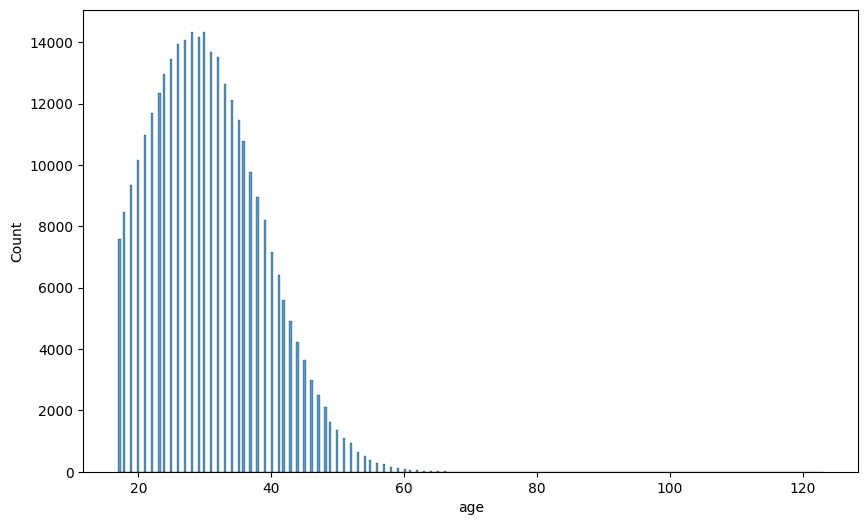

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=data, x='age')
plt.show()

In [ ]:
age_mean = data['age'].mean()
age_std = data['age'].std()
age_min = data['age'].min()
age_max = data['age'].max()

print('Age mean: ', age_mean)
print('Age std: ', age_std)
print('Age min: ', age_min)
print('Age max: ', age_max)

Age mean:  30.569857685009488
Age std:  8.271801801806394
Age min:  17
Age max:  123


<Axes: xlabel='age', ylabel='count'>

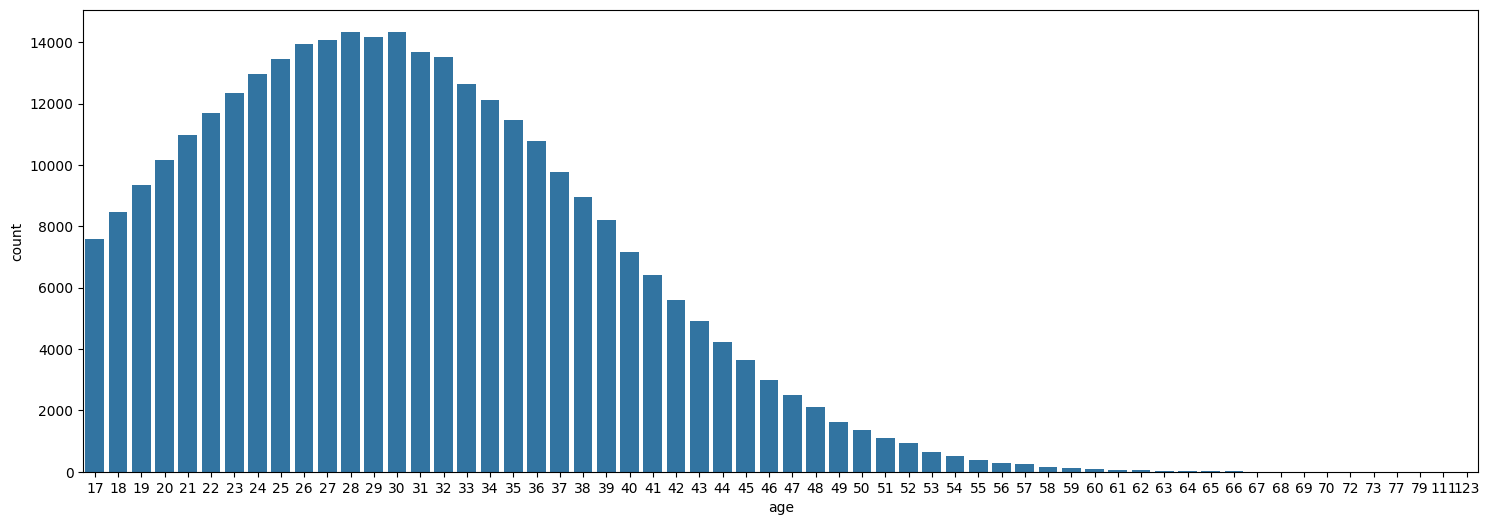

In [7]:
fig, ax=plt.subplots(figsize=(18, 6))
sns.countplot(data=data, x='age', ax=ax)

### total_pages_visited

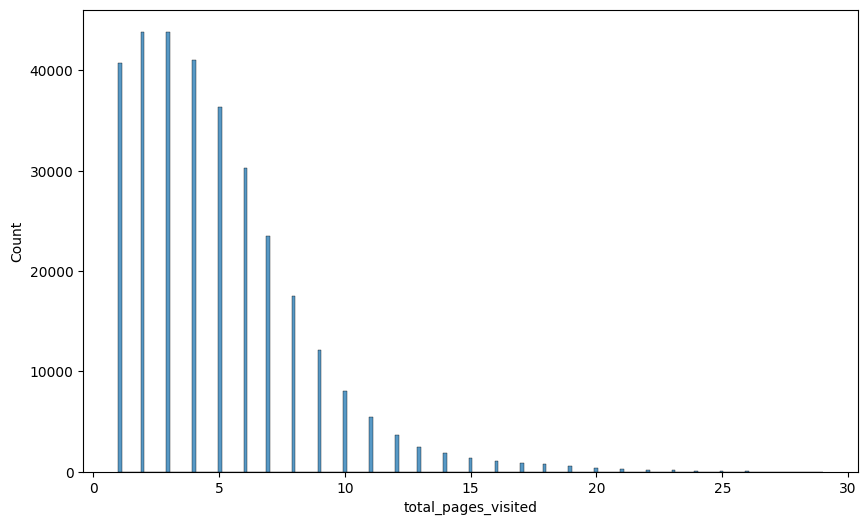

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=data, x='total_pages_visited')
plt.show()

In [ ]:
total_pages_visited_mean = data['total_pages_visited'].mean()
total_pages_visited_std = data['total_pages_visited'].std()
total_pages_visited_min = data['total_pages_visited'].min()
total_pages_visited_max = data['total_pages_visited'].max()

print(  'total_pages_visited mean: ', total_pages_visited_mean)
print(  'total_pages_visited std: ', total_pages_visited_std)
print(  'total_pages_visited min: ', total_pages_visited_min)
print(  'total_pages_visited max: ', total_pages_visited_max)

total_pages_visited mean:  4.872966476913346
total_pages_visited std:  3.3411037579465486
total_pages_visited min:  1
total_pages_visited max:  29


### Discrete values - new_user

*  new_user
*  converted



In [ ]:
data['new_user'].unique()

array([1, 0])

In [ ]:
data['converted'].unique()

array([0, 1])

### Categorical variables
* country
* source

In [ ]:
data['country'].unique()

array(['UK', 'US', 'China', 'Germany'], dtype=object)

In [ ]:
data['source'].unique()

array(['Ads', 'Seo', 'Direct'], dtype=object)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316200 entries, 0 to 316199
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              316200 non-null  object
 1   age                  316200 non-null  int64 
 2   new_user             316200 non-null  int64 
 3   source               316200 non-null  object
 4   total_pages_visited  316200 non-null  int64 
 5   converted            316200 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 14.5+ MB


In [ ]:
#data.describe(include='all')
data.describe()

,age,new_user,total_pages_visited,converted
count,316200.000000,316200.000000,316200.000000,316200.000000
mean,30.569858,0.685465,4.872966,0.032258
std,8.271802,0.464331,3.341104,0.176685
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000


## Unique values

In [ ]:
for column in data.columns:
    uniques = sorted(data[column].unique())
    print('{0:20s} {1:5d}\t'.format(column, len(uniques)), uniques[:5])

country                  4	 ['China', 'Germany', 'UK', 'US']
age                     60	 [np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
new_user                 2	 [np.int64(0), np.int64(1)]
source                   3	 ['Ads', 'Direct', 'Seo']
total_pages_visited     29	 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
converted                2	 [np.int64(0), np.int64(1)]


In [ ]:
data.columns

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited',
       'converted'],
      dtype='object')

t# Remove Outliers
Typically, age should be below 100. So, first let check outliers and clean the dataset

In [ ]:
data[data['age'] > 90]

,country,age,new_user,source,total_pages_visited,converted
90928,Germany,123,0,Seo,15,1
295581,UK,111,0,Ads,10,1


In [ ]:
data[data['age'] > 100]

,country,age,new_user,source,total_pages_visited,converted
90928,Germany,123,0,Seo,15,1
295581,UK,111,0,Ads,10,1


There are only two records that is invalid, let's first remove them directly

In [ ]:
data = data[data['age'] < 100]

### Check after removing outliers

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 316198 entries, 0 to 316199
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              316198 non-null  object
 1   age                  316198 non-null  int64 
 2   new_user             316198 non-null  int64 
 3   source               316198 non-null  object
 4   total_pages_visited  316198 non-null  int64 
 5   converted            316198 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 16.9+ MB


In [ ]:
data.describe()

,age,new_user,total_pages_visited,converted
count,316198.000000,316198.000000,316198.000000,316198.000000
mean,30.569311,0.685469,4.872918,0.032252
std,8.268958,0.464329,3.341053,0.176669
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,79.000000,1.000000,29.000000,1.000000


# Exploratory Data Analysis

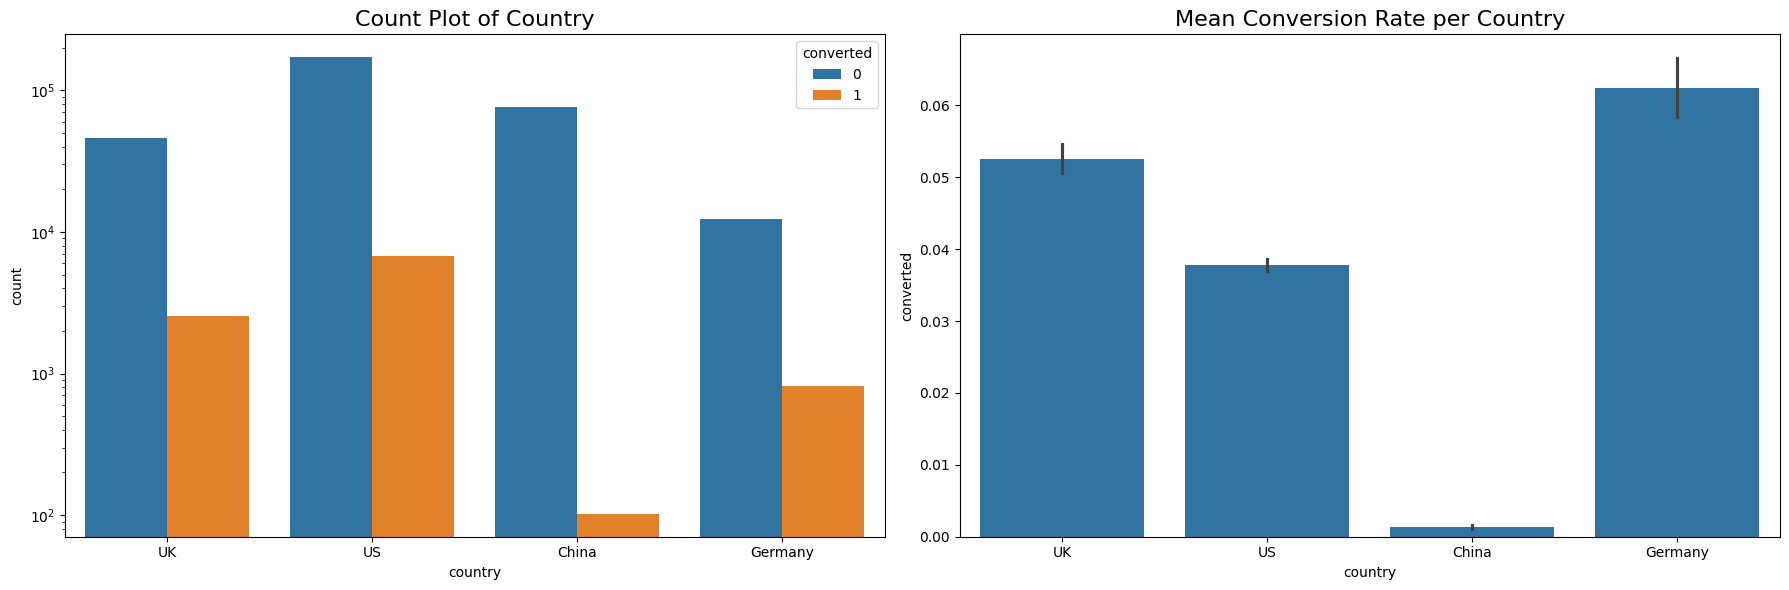

In [ ]:
# Visualization of different countries
grouped = data[['country', 'converted']].groupby('country').mean().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.countplot(x='country', hue='converted', data=data, ax=ax[0])
ax[0].set_title('Count Plot of Country', fontsize=16)
ax[0].set_yscale('log')

sns.barplot(x='country', y='converted', data=data, ax=ax[1]);
ax[1].set_title('Mean Conversion Rate per Country', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
data.head()
grouped.head()

,new_user,converted
0,0,0.072002
1,1,0.014021


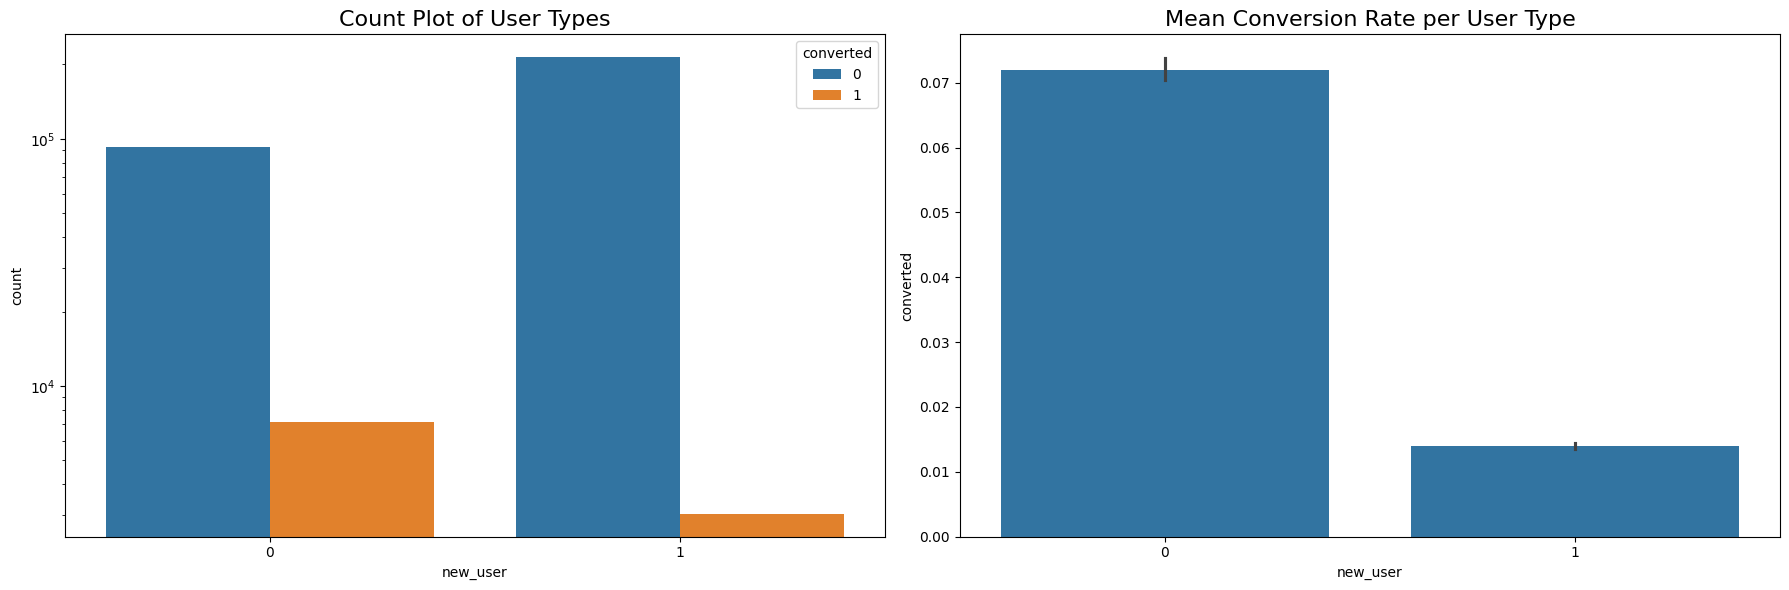

In [ ]:
# Visualization of different user types
grouped = data[['new_user', 'converted']].groupby('new_user').mean().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.countplot(x='new_user', hue='converted', data=data, ax=ax[0])
ax[0].set_title('Count Plot of User Types', fontsize=16)
ax[0].set_yscale('log')
sns.barplot(x='new_user', y='converted', data=data, ax=ax[1]);
ax[1].set_title('Mean Conversion Rate per User Type', fontsize=16)
plt.tight_layout()
plt.show()

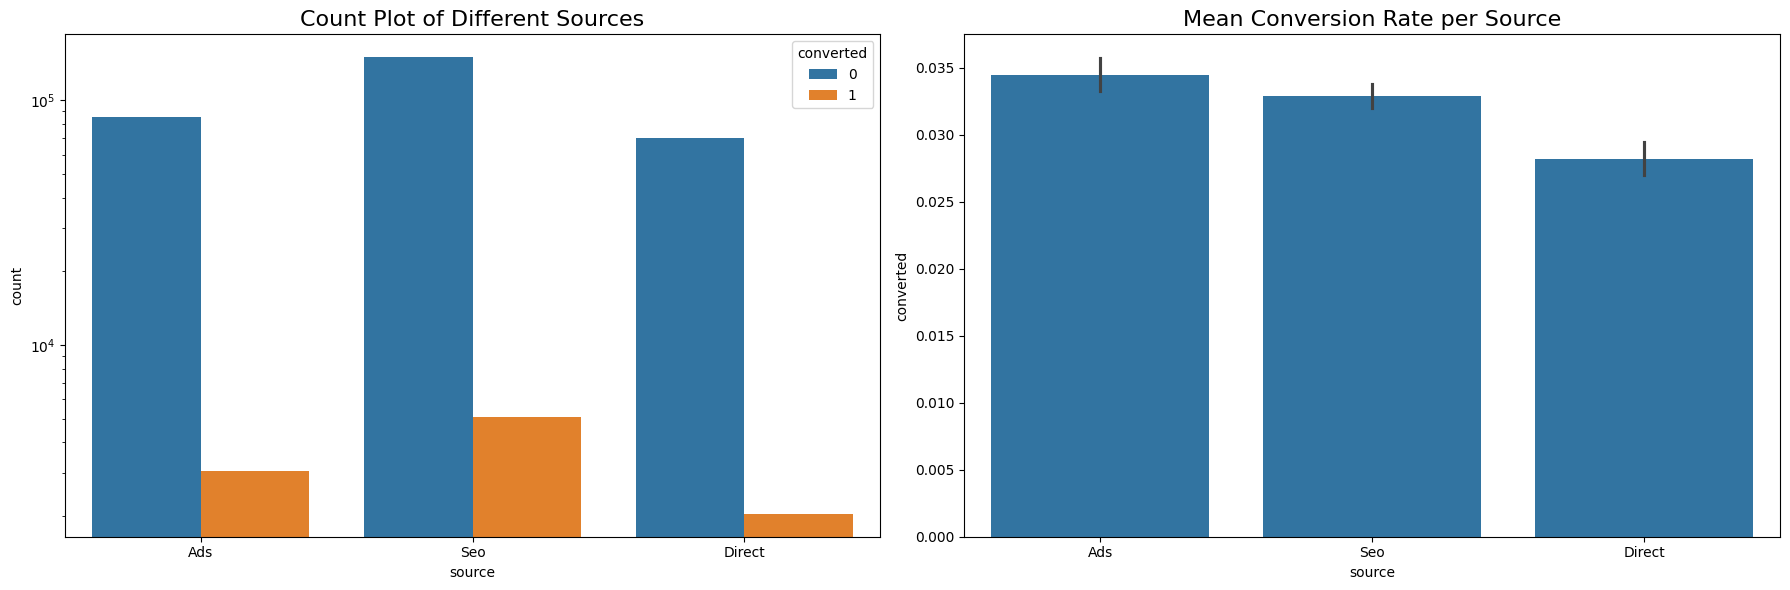

In [ ]:
# Visualization of different sources
grouped = data[['source', 'converted']].groupby('source').mean().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.countplot(x='source', hue='converted', data=data, ax=ax[0])
ax[0].set_title('Count Plot of Different Sources', fontsize=16)
ax[0].set_yscale('log')
sns.barplot(x='source', y='converted', data=data, ax=ax[1]);
ax[1].set_title('Mean Conversion Rate per Source', fontsize=16)
plt.tight_layout()
plt.show()

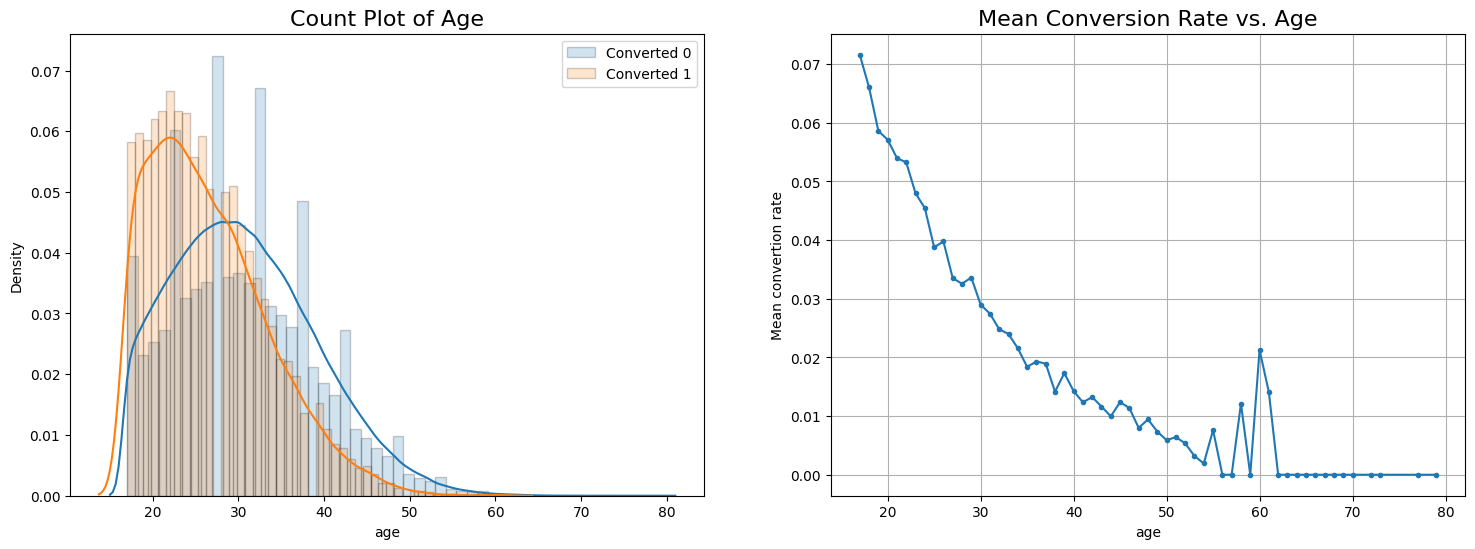

In [ ]:
# Visualization of different sources
grouped = data[['age', 'converted']].groupby('age').mean().reset_index()
hist_kws={'histtype': 'bar', 'edgecolor':'black', 'alpha': 0.2}

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.distplot(data[data['converted'] == 0]['age'], label='Converted 0',
             ax=ax[0], hist_kws=hist_kws)
sns.distplot(data[data['converted'] == 1]['age'], label='Converted 1',
             ax=ax[0], hist_kws=hist_kws)
ax[0].set_title('Count Plot of Age', fontsize=16)
ax[0].legend()
ax[1].plot(grouped['age'], grouped['converted'], '.-')
ax[1].set_title('Mean Conversion Rate vs. Age', fontsize=16)
ax[1].set_xlabel('age')
ax[1].set_ylabel('Mean convertion rate')
ax[1].grid(True)
plt.show()

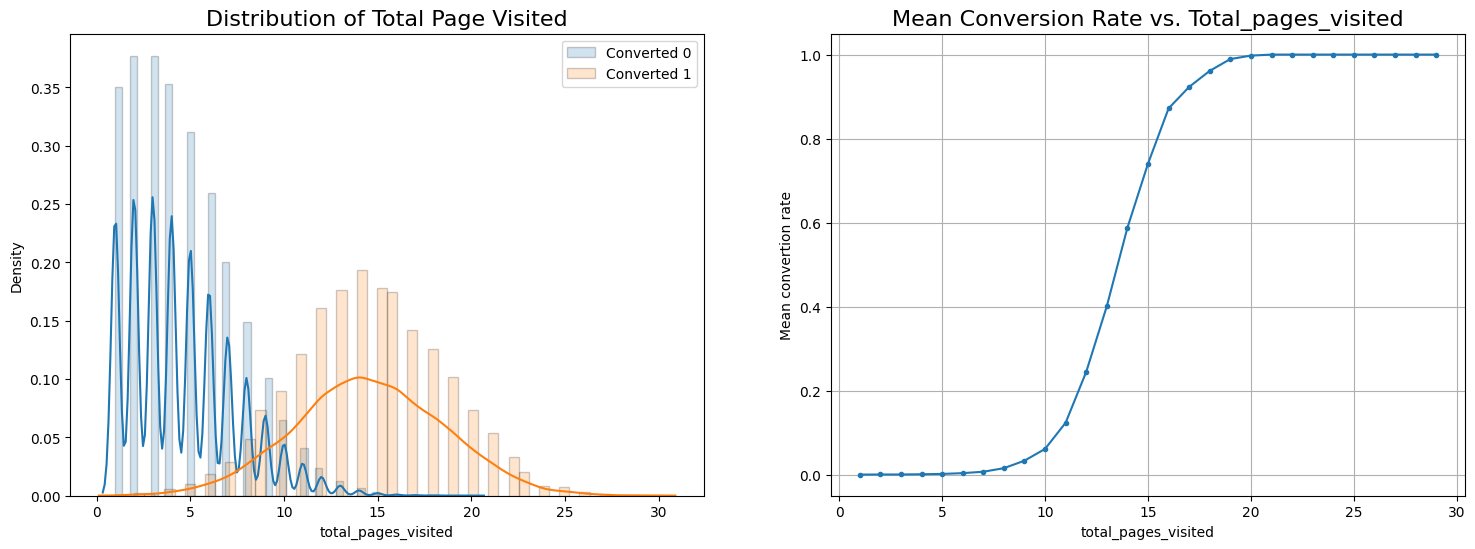

In [ ]:
# Visualization of different sources
grouped = data[['total_pages_visited', 'converted']].groupby('total_pages_visited').mean().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.distplot(data[data['converted'] == 0]['total_pages_visited'],
             label='Converted 0', ax=ax[0], hist_kws=hist_kws)
sns.distplot(data[data['converted'] == 1]['total_pages_visited'],
             label='Converted 1', ax=ax[0], hist_kws=hist_kws)
ax[0].set_title('Distribution of Total Page Visited', fontsize=16)
ax[0].legend()
ax[1].plot(grouped['total_pages_visited'], grouped['converted'], '.-')
ax[1].set_title('Mean Conversion Rate vs. Total_pages_visited', fontsize=16)
ax[1].set_xlabel('total_pages_visited')
ax[1].set_ylabel('Mean convertion rate')
ax[1].grid(True)
plt.show()